# Telecom Customer Churn Prediction

## Business Problem

Customer churn is one of the biggest challenges for telecom companies because acquiring a new customer costs much more than retaining an existing one.

The objective of this project is to analyze customer behavior, identify the factors that influence churn, and develop a machine learning model that predicts whether a customer is likely to leave the company.

The results will be used to recommend business strategies that improve customer retention and reduce revenue loss.

Load Data


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

client = pd.read_csv("Client.csv")
record = pd.read_csv("Record.csv")

df = client.merge(record,on="Customer_ID")

print(df.shape)

df.head()

(100000, 100)


,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57


Dataset Overview

In [6]:
print(df.info())

print(df.describe())

print(df.describe(include="object"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   uniqsubs          100000 non-null  int64  
 1   actvsubs          100000 non-null  int64  
 2   new_cell          100000 non-null  object 
 3   crclscod          100000 non-null  object 
 4   asl_flag          100000 non-null  object 
 5   totcalls          100000 non-null  int64  
 6   totmou            100000 non-null  float64
 7   totrev            100000 non-null  float64
 8   adjrev            100000 non-null  float64
 9   adjmou            100000 non-null  float64
 10  adjqty            100000 non-null  int64  
 11  avgrev            100000 non-null  float64
 12  avgmou            100000 non-null  float64
 13  avgqty            100000 non-null  float64
 14  avg3mou           100000 non-null  int64  
 15  avg3qty           100000 non-null  int64  
 16  avg3rev           10

Missing Values

In [7]:
missing = df.isnull().sum()

missing = missing[missing>0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing":missing,
    "Percentage":100*missing/len(df)
})

missing_df.head(20)

,Missing,Percentage
numbcars,49366,49.366
dwllsize,38308,38.308
HHstatin,37923,37.923
ownrent,33706,33.706
dwlltype,31909,31.909
lor,30190,30.190
income,25436,25.436
adults,23019,23.019
infobase,22079,22.079
hnd_webcap,10189,10.189


Visualization

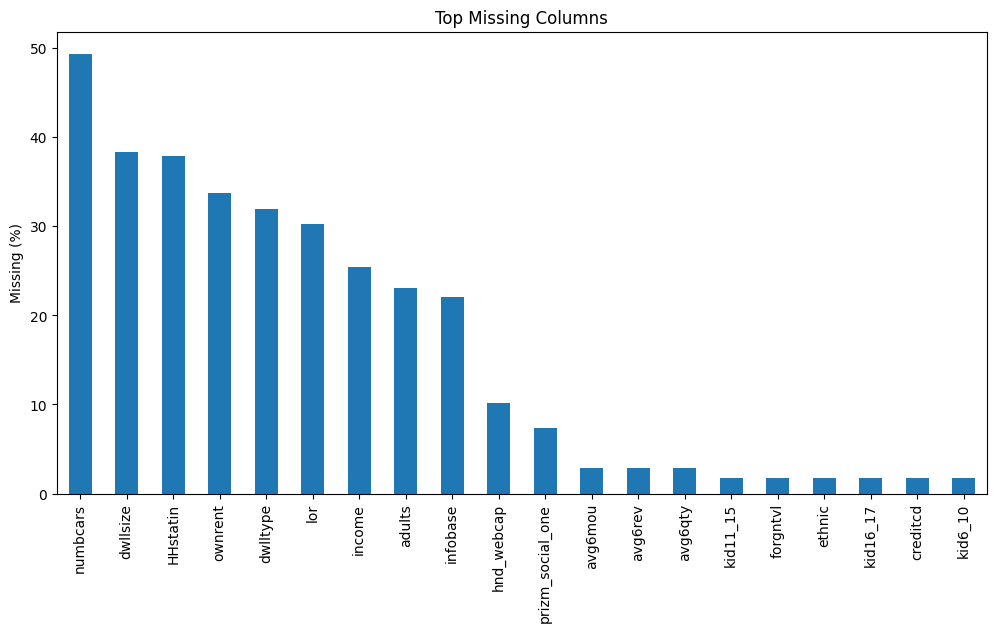

In [8]:
plt.figure(figsize=(12,6))

missing_df["Percentage"].head(20).plot(kind="bar")

plt.ylabel("Missing (%)")

plt.title("Top Missing Columns")

plt.show()

Churn Distribution

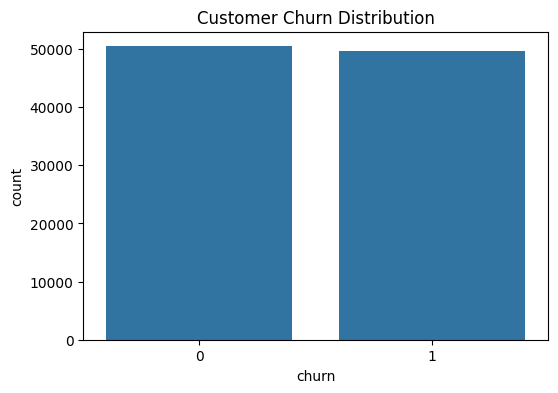

In [9]:
df["churn"].value_counts()
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="churn")

plt.title("Customer Churn Distribution")

plt.show()

**Exploratory Data Analysis (EDA)**


Customer Tenure vs Churn

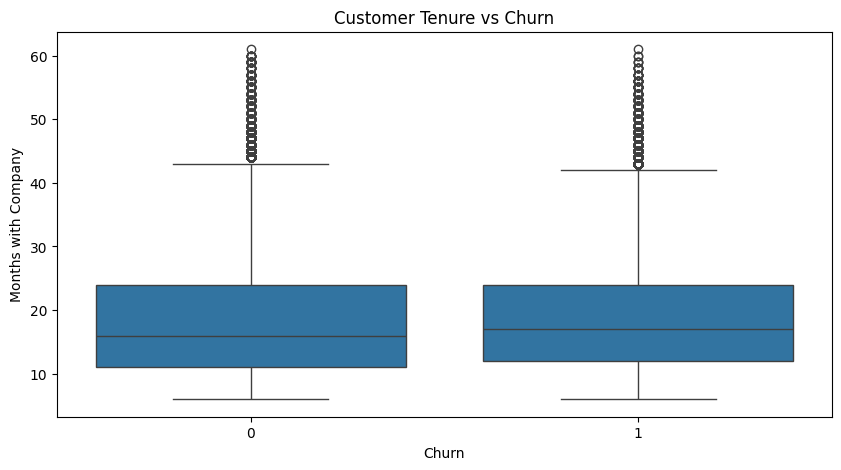

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(x='churn', y='months', data=df)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Months with Company")
plt.show()

Revenue vs Churn

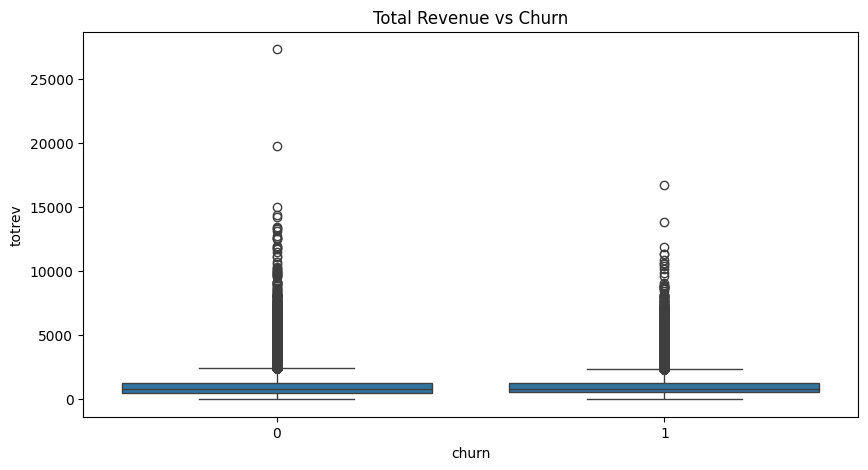

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(x='churn', y='totrev', data=df)

plt.title("Total Revenue vs Churn")
plt.show()

Also check average revenue

In [12]:
df.groupby("churn")["totrev"].mean()

,totrev
churn,
0,1034.475849
1,1029.329041


Monthly Usage

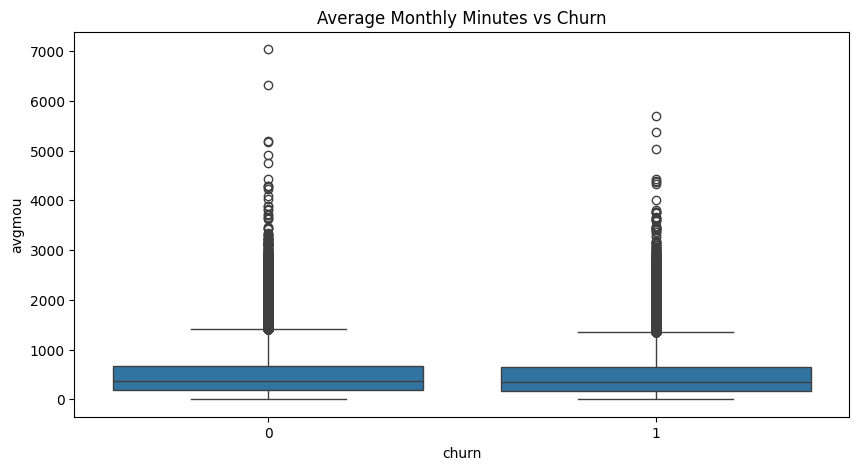

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x="churn",y="avgmou",data=df)

plt.title("Average Monthly Minutes vs Churn")

plt.show()

Also

In [14]:
df.groupby("churn")["avgmou"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,50438.0,494.167895,451.175568,0.0,178.2825,365.545,669.4300,7040.13
1,49562.0,473.100540,424.923088,0.0,174.1575,354.195,642.9025,5687.56


Total Minutes

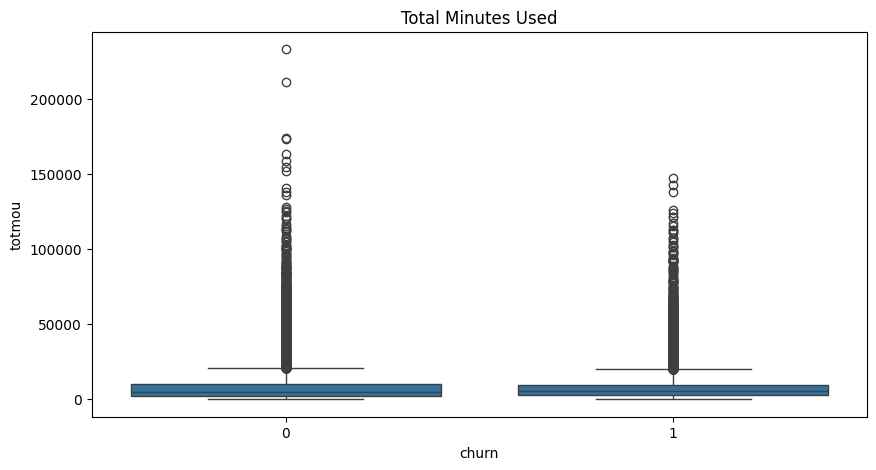

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x="churn",y="totmou",data=df)

plt.title("Total Minutes Used")

plt.show()

Customer Revenue Distribution

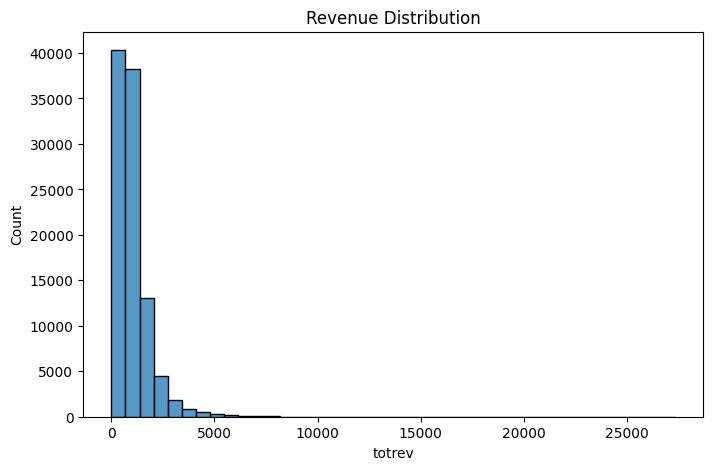

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["totrev"],bins=40)

plt.title("Revenue Distribution")

plt.show()

Correlation Heatmap

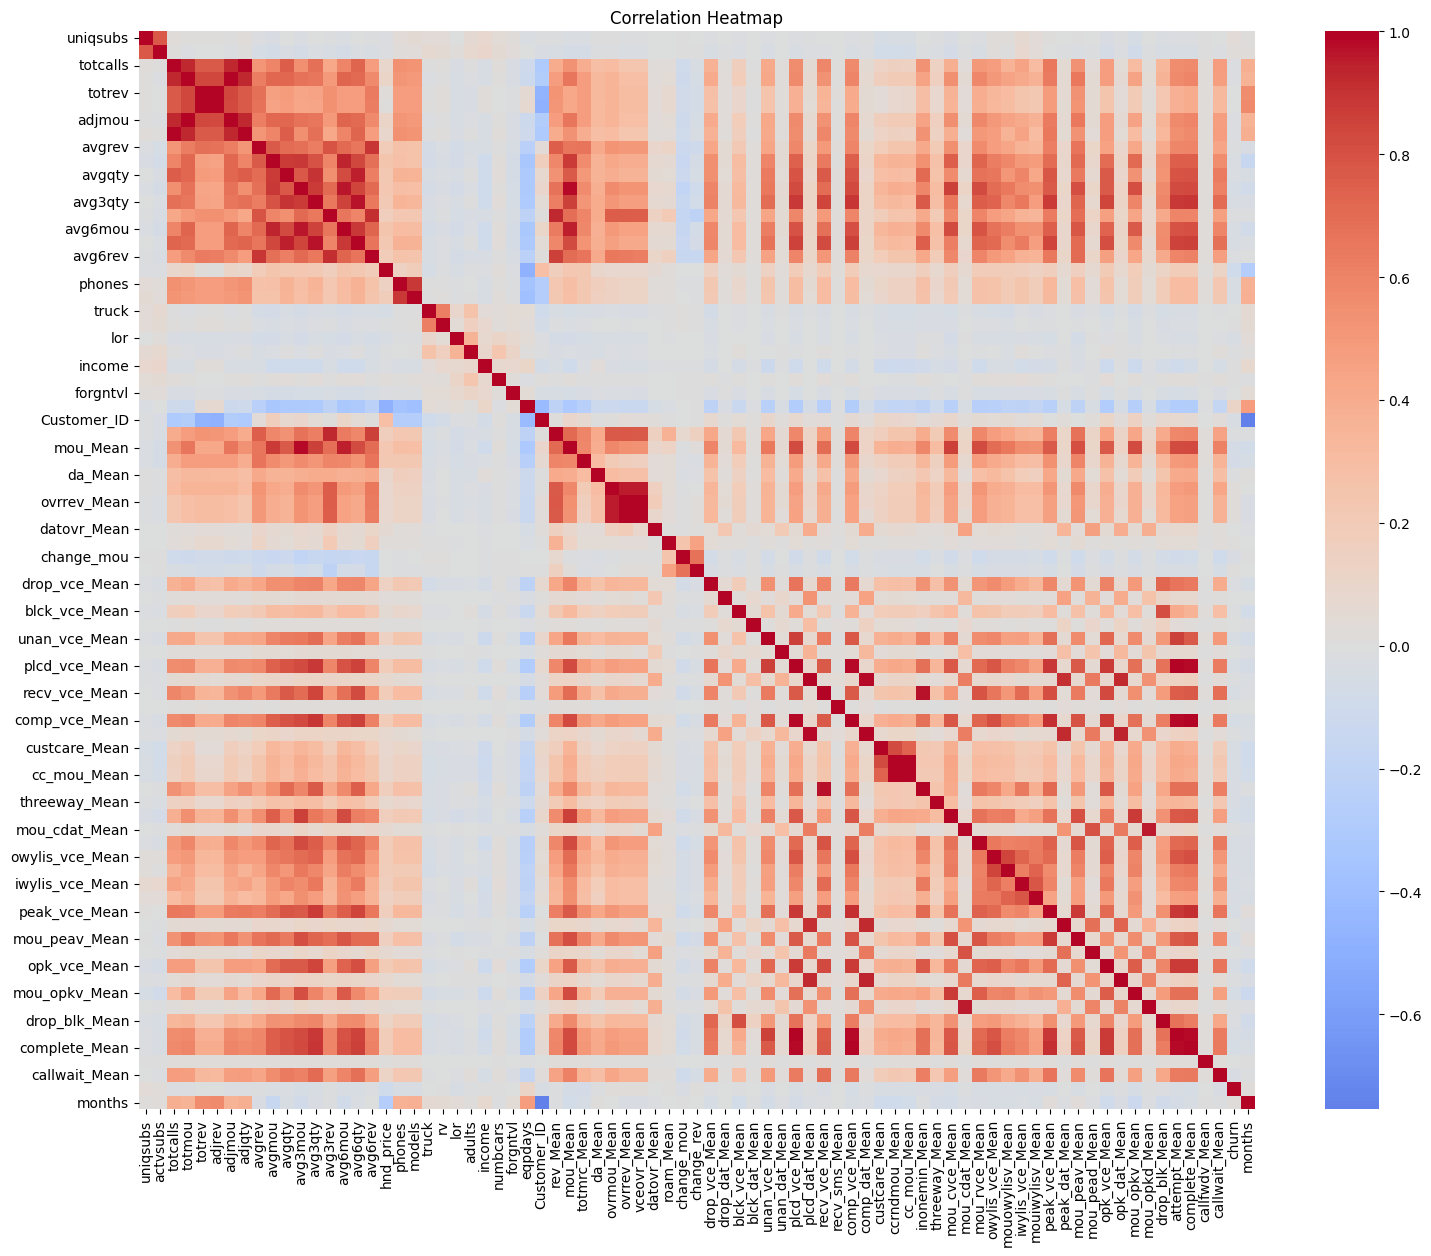

In [17]:
numeric=df.select_dtypes(include=np.number)

corr=numeric.corr()

plt.figure(figsize=(18,14))

sns.heatmap(corr,
            cmap="coolwarm",
            center=0)

plt.title("Correlation Heatmap")

plt.show()

Strongest Correlations with Churn

In [18]:
corr["churn"].sort_values(ascending=False)

,churn
churn,1.000000
eqpdays,0.112691
uniqsubs,0.039882
vceovr_Mean,0.024240
ovrrev_Mean,0.023736
...,...
complete_Mean,-0.051740
mou_cvce_Mean,-0.052042
mou_Mean,-0.057027
totmrc_Mean,-0.068558


Missing Values

In [19]:
missing=df.isnull().sum().sort_values(ascending=False)

missing=missing[missing>0]

missing

,0
numbcars,49366
dwllsize,38308
HHstatin,37923
ownrent,33706
dwlltype,31909
lor,30190
income,25436
adults,23019
infobase,22079
hnd_webcap,10189


Percentage

In [20]:
missing_percent=100*missing/len(df)

missing_percent.head(20)

,0
numbcars,49.366
dwllsize,38.308
HHstatin,37.923
ownrent,33.706
dwlltype,31.909
lor,30.190
income,25.436
adults,23.019
infobase,22.079
hnd_webcap,10.189


**Data Cleaning**

Numerical columns:

In [21]:
num_cols=df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col]=df[col].fillna(df[col].median())

Categorical columns:

In [22]:
cat_cols=df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

**Feature Engineering**

Split features

In [23]:
X=df.drop("churn",axis=1)

y=df["churn"]

Categorical columns:

In [24]:
cat_cols=X.select_dtypes(include="object").columns

num_cols=X.select_dtypes(exclude="object").columns

Preprocessing:

In [25]:
preprocessor=ColumnTransformer(

[
("num",StandardScaler(),num_cols),

("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols)

]
)

**Train/Test Split**

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(80000, 99)
(20000, 99)


**Logistic Regression**

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

y_pred_log = logistic_model.predict(X_test)

Evaluation

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))

prob_log = logistic_model.predict_proba(X_test)[:,1]
print("ROC AUC  :", roc_auc_score(y_test, prob_log))

Accuracy : 0.59755
Precision: 0.593458412762115
Recall   : 0.5967514124293786
F1 Score : 0.595100357160823
ROC AUC  : 0.6311042827156536


Confusion Matrix

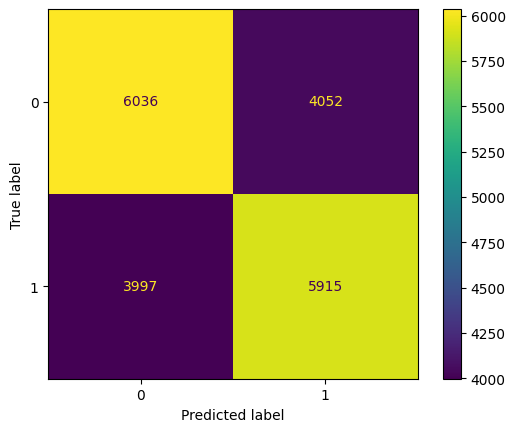

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test
)

plt.show()

**Decision Tree**

In [30]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=8
    ))
])

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

Evaluation

In [31]:
print("Accuracy :", accuracy_score(y_test,y_pred_tree))
print("Precision:", precision_score(y_test,y_pred_tree))
print("Recall   :", recall_score(y_test,y_pred_tree))
print("F1 Score :", f1_score(y_test,y_pred_tree))

prob_tree = tree_model.predict_proba(X_test)[:,1]

print("ROC AUC :", roc_auc_score(y_test,prob_tree))

Accuracy : 0.59685
Precision: 0.597675647120972
Recall   : 0.5707223567393059
F1 Score : 0.583888114775249
ROC AUC : 0.6405290625706055


**Random Forest**

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

Evaluation

In [35]:
print("Accuracy :", accuracy_score(y_test,y_pred_rf))
print("Precision:", precision_score(y_test,y_pred_rf))
print("Recall   :", recall_score(y_test,y_pred_rf))
print("F1 Score :", f1_score(y_test,y_pred_rf))

prob_rf = rf_model.predict_proba(X_test)[:,1]

print("ROC AUC :", roc_auc_score(y_test,prob_rf))

Accuracy : 0.62525
Precision: 0.6206208204411618
Recall   : 0.6273204196933011
F1 Score : 0.6239526365962571
ROC AUC : 0.6752200290390489


**Compare Models**

In [36]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,y_pred_tree),
        accuracy_score(y_test,y_pred_rf)
    ],
    "Precision":[
        precision_score(y_test,y_pred_log),
        precision_score(y_test,y_pred_tree),
        precision_score(y_test,y_pred_rf)
    ],
    "Recall":[
        recall_score(y_test,y_pred_log),
        recall_score(y_test,y_pred_tree),
        recall_score(y_test,y_pred_rf)
    ],
    "F1":[
        f1_score(y_test,y_pred_log),
        f1_score(y_test,y_pred_tree),
        f1_score(y_test,y_pred_rf)
    ],
    "ROC_AUC":[
        roc_auc_score(y_test,prob_log),
        roc_auc_score(y_test,prob_tree),
        roc_auc_score(y_test,prob_rf)
    ]
})

results.sort_values("ROC_AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,0.62525,0.620621,0.627320,0.623953,0.675220
1,Decision Tree,0.59685,0.597676,0.570722,0.583888,0.640529
0,Logistic Regression,0.59755,0.593458,0.596751,0.595100,0.631104
